# 11 — Feature Engineering & Interaction Features for Road Accident Severity

## Objective

This notebook converts the **screened feature interactions from Notebook 10A** into engineered categorical interaction features and tests whether they improve severity prediction.

The current best reference model is **HistGradientBoosting** from Notebook 08:

- Accuracy: 0.6758
- Macro Precision: 0.6791
- Macro Recall: 0.4232
- Macro F1: 0.4245
- ROC-AUC: 0.7759

The purpose here is **not** to assume that interactions improve the model. We will test that empirically.

### Leakage control

- Interaction candidates were screened on the training data only.
- The target is never used to construct an interaction feature.
- The test set is used only for final evaluation.
- No outcome-derived injury columns are reintroduced.


In [1]:
# Imports and configuration
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DATA_DIR = "../data"

print("Ready.")


Ready.


## 1. Load the existing preprocessed data

We reuse the exact train/test matrices and Information Gain feature mapping created earlier.

No preprocessing is redone here.


In [2]:
X_train = sparse.load_npz(os.path.join(DATA_DIR, "X_train_final.npz")).tocsr()
X_test = sparse.load_npz(os.path.join(DATA_DIR, "X_test_final.npz")).tocsr()

y_train = np.load(os.path.join(DATA_DIR, "y_train_encoded.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test_encoded.npy"))

feature_names = pd.read_csv(
    os.path.join(DATA_DIR, "final_feature_names.csv")
)["feature_name"].tolist()

selected_df = pd.read_csv(
    os.path.join(DATA_DIR, "selected_features_ig.csv")
)
selected_original = selected_df["original_feature"].dropna().tolist()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Selected original features:", len(selected_original))


X_train: (160278, 361)
X_test : (40070, 361)
Selected original features: 26


## 2. Define the controlled interaction shortlist

Notebook 10A identified many statistically interesting combinations. We deliberately carry forward a **small, controlled subset** rather than creating dozens of engineered features.

The shortlist emphasizes interactions that are both data-supported and interpretable as crash context.

### Two-way interactions tested

1. `ACCIDENT_TYPE × SPEED_ZONE`
2. `DCA_CODE_DESCRIPTION × SPEED_ZONE`
3. `SPEED_ZONE × DRIVER`
4. `SPEED_ZONE × PASSENGERVEHICLE`
5. `ACCIDENT_TYPE × MOTORCYCLE`
6. `ACCIDENT_TYPE × MOTORCYCLIST`
7. `DEG_URBAN_NAME × DRIVER`
8. `ACCIDENT_TYPE × POLICE_ATTEND`

The final item is included as a representative context interaction because the screening showed that `POLICE_ATTEND` participates in several strong combinations. We do not include every police-attendance pair to avoid uncontrolled feature proliferation.

### Engineering principle

Interactions are created at the **original-feature level**, then encoded as categorical combinations. We do not multiply already one-hot encoded columns manually.


In [3]:
interaction_pairs = [
    ("ACCIDENT_TYPE", "SPEED_ZONE"),
    ("DCA_CODE_DESCRIPTION", "SPEED_ZONE"),
    ("SPEED_ZONE", "DRIVER"),
    ("SPEED_ZONE", "PASSENGERVEHICLE"),
    ("ACCIDENT_TYPE", "MOTORCYCLE"),
    ("ACCIDENT_TYPE", "MOTORCYCLIST"),
    ("DEG_URBAN_NAME", "DRIVER"),
    ("ACCIDENT_TYPE", "POLICE_ATTEND"),
]

# Keep only pairs that are represented in the selected original feature set.
interaction_pairs = [
    pair for pair in interaction_pairs
    if pair[0] in selected_original and pair[1] in selected_original
]

print("Interactions carried forward:")
for i, pair in enumerate(interaction_pairs, 1):
    print(f"{i}. {pair[0]} × {pair[1]}")


Interactions carried forward:
1. ACCIDENT_TYPE × SPEED_ZONE
2. DCA_CODE_DESCRIPTION × SPEED_ZONE
3. SPEED_ZONE × DRIVER
4. SPEED_ZONE × PASSENGERVEHICLE
5. ACCIDENT_TYPE × MOTORCYCLE
6. ACCIDENT_TYPE × MOTORCYCLIST
7. DEG_URBAN_NAME × DRIVER
8. ACCIDENT_TYPE × POLICE_ATTEND


## 3. Reconstruct original-feature values from the encoded matrices

The final matrices contain one-hot encoded columns, so we need to recover the original categorical values for the selected interaction variables.

For one-hot features, the active category is identified from the feature-name suffix.

For numerical selected features, we use the encoded value directly only when an interaction requires it; the current shortlist is primarily categorical/binary.


In [4]:
# Helper to identify encoded columns belonging to one original feature.
# Exact matching is used for numeric features; prefix matching is used only for
# categorical one-hot groups, avoiding collisions such as DCA_CODE vs DCA_CODE_DESCRIPTION.

categorical_originals = {
    "ACCIDENT_TYPE", "DAY_OF_WEEK", "DCA_CODE_DESCRIPTION",
    "LIGHT_CONDITION", "POLICE_ATTEND", "ROAD_GEOMETRY",
    "SPEED_ZONE", "RUN_OFFROAD", "ROAD_TYPE", "LGA_NAME",
    "DTP_REGION", "DEG_URBAN_NAME", "SRNS", "RMA",
    "DIVIDED", "STAT_DIV_NAME"
}

def get_original_columns(original_feature):
    if original_feature == "ROAD_NAME":
        exact = [
            i for i, n in enumerate(feature_names)
            if n == "ROAD_NAME_FREQ"
        ]
        return exact

    if original_feature in categorical_originals:
        return [
            i for i, n in enumerate(feature_names)
            if n.startswith(original_feature + "_")
        ]

    return [
        i for i, n in enumerate(feature_names)
        if n == original_feature
    ]

def decode_categorical_from_onehot(X, original_feature):
    cols = get_original_columns(original_feature)
    names = [feature_names[i] for i in cols]

    block = X[:, cols]

    if sparse.issparse(block):
        block = block.tocsr()

    arr = block.toarray()

    values = []
    for row in arr:
        active = np.flatnonzero(row > 0.5)
        if len(active) == 0:
            values.append("Missing")
        else:
            values.append(names[active[0]])

    # Remove the original-feature prefix from the one-hot name for readability.
    prefix = original_feature + "_"
    values = [
        v[len(prefix):] if v.startswith(prefix) else v
        for v in values
    ]

    return pd.Series(values)

decoded_train = {}
decoded_test = {}

for f in sorted(set(sum(([a,b] for a,b in interaction_pairs), []))):
    decoded_train[f] = decode_categorical_from_onehot(X_train, f)
    decoded_test[f] = decode_categorical_from_onehot(X_test, f)

print("Decoded interaction variables:")
for f in decoded_train:
    print(f, "->", decoded_train[f].nunique(), "levels")


Decoded interaction variables:
ACCIDENT_TYPE -> 9 levels
DCA_CODE_DESCRIPTION -> 81 levels
DEG_URBAN_NAME -> 8 levels
DRIVER -> 2 levels
MOTORCYCLE -> 2 levels
MOTORCYCLIST -> 2 levels
PASSENGERVEHICLE -> 2 levels
POLICE_ATTEND -> 3 levels
SPEED_ZONE -> 13 levels


## 4. Create interaction features

Each pair becomes a single categorical feature:

`ACCIDENT_TYPE × SPEED_ZONE`

For example, a crash type and its speed-zone category become one combined level.

This allows the downstream model to learn different effects for combinations instead of treating the two variables only as independent inputs.


In [5]:
def make_interaction_series(decoded, a, b):
    return (
        decoded[a].astype(str)
        + " × "
        + decoded[b].astype(str)
    )

train_interactions = {}
test_interactions = {}

for a, b in interaction_pairs:
    name = f"{a}__X__{b}"
    train_interactions[name] = make_interaction_series(decoded_train, a, b)
    test_interactions[name] = make_interaction_series(decoded_test, a, b)

train_interaction_df = pd.DataFrame(train_interactions)
test_interaction_df = pd.DataFrame(test_interactions)

print("Interaction feature matrix:")
print(train_interaction_df.shape)
display(train_interaction_df.head())


Interaction feature matrix:
(160278, 8)


,ACCIDENT_TYPE__X__SPEED_ZONE,DCA_CODE_DESCRIPTION__X__SPEED_ZONE,SPEED_ZONE__X__DRIVER,SPEED_ZONE__X__PASSENGERVEHICLE,ACCIDENT_TYPE__X__MOTORCYCLE,ACCIDENT_TYPE__X__MOTORCYCLIST,DEG_URBAN_NAME__X__DRIVER,ACCIDENT_TYPE__X__POLICE_ATTEND
0,Struck animal × 100 km/hr,STRUCK ANIMAL × 100 km/hr,100 km/hr × Missing,100 km/hr × Missing,Struck animal × Missing,Struck animal × Missing,TOWNS × Missing,Struck animal × No
1,Collision with vehicle × 50 km/hr,VEHICLE COLLIDES WITH VEHICLE PARKED ON LEFT O...,50 km/hr × Missing,50 km/hr × PASSENGERVEHICLE,Collision with vehicle × Missing,Collision with vehicle × Missing,LARGE_PROVINCIAL_CITIES × Missing,Collision with vehicle × Yes
2,No collision and no object struck × 40 km/hr,OUT OF CONTROL ON CARRIAGEWAY (ON STRAIGHT) × ...,40 km/hr × Missing,40 km/hr × Missing,No collision and no object struck × Missing,No collision and no object struck × Missing,MELB_URBAN × Missing,No collision and no object struck × Yes
3,Collision with a fixed object × 100 km/hr,RIGHT OFF CARRIAGEWAY INTO OBJECT/PARKED VEHIC...,100 km/hr × Missing,100 km/hr × Missing,Collision with a fixed object × Missing,Collision with a fixed object × Missing,RURAL_VICTORIA × Missing,Collision with a fixed object × Yes
4,Collision with vehicle × 50 km/hr,RIGHT THROUGH × 50 km/hr,50 km/hr × Missing,50 km/hr × Missing,Collision with vehicle × Missing,Collision with vehicle × Missing,MELB_URBAN × Missing,Collision with vehicle × No


## 5. Control rare interaction levels

Some combinations may occur only a handful of times.

Rare levels are grouped into `Other` using a **training-set frequency threshold**. This reduces sparsity and ensures that a combination observed only a few times does not create an unstable feature.

The same mapping learned from training is applied to the test set.


In [6]:
MIN_INTERACTION_SUPPORT = 100

train_clean = train_interaction_df.copy()
test_clean = test_interaction_df.copy()

rare_mappings = {}

for col in train_clean.columns:
    counts = train_clean[col].value_counts()
    keep = set(counts[counts >= MIN_INTERACTION_SUPPORT].index)

    train_clean[col] = train_clean[col].where(
        train_clean[col].isin(keep), "Other"
    )

    test_clean[col] = test_clean[col].where(
        test_clean[col].isin(keep), "Other"
    )

    rare_mappings[col] = keep

print("Interaction levels after rare-category grouping:")
for col in train_clean.columns:
    print(
        f"{col}:",
        train_clean[col].nunique(),
        "levels |",
        "kept original levels:",
        len(rare_mappings[col])
    )


Interaction levels after rare-category grouping:
ACCIDENT_TYPE__X__SPEED_ZONE: 61 levels | kept original levels: 60
DCA_CODE_DESCRIPTION__X__SPEED_ZONE: 241 levels | kept original levels: 240
SPEED_ZONE__X__DRIVER: 22 levels | kept original levels: 21
SPEED_ZONE__X__PASSENGERVEHICLE: 22 levels | kept original levels: 21
ACCIDENT_TYPE__X__MOTORCYCLE: 18 levels | kept original levels: 17
ACCIDENT_TYPE__X__MOTORCYCLIST: 18 levels | kept original levels: 17
DEG_URBAN_NAME__X__DRIVER: 16 levels | kept original levels: 16
ACCIDENT_TYPE__X__POLICE_ATTEND: 18 levels | kept original levels: 17


## 6. One-hot encode the engineered interactions

The original 136 selected encoded features remain unchanged.

The interaction features are appended as additional one-hot columns.

`handle_unknown="ignore"` ensures an unseen test combination does not cause an encoding failure.


In [7]:
interaction_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32
)

train_interaction_encoded = interaction_encoder.fit_transform(train_clean)
test_interaction_encoded = interaction_encoder.transform(test_clean)

X_train_engineered = sparse.hstack(
    [X_train, train_interaction_encoded],
    format="csr",
    dtype=np.float32
)

X_test_engineered = sparse.hstack(
    [X_test, test_interaction_encoded],
    format="csr",
    dtype=np.float32
)

print("Original feature matrix:", X_train.shape)
print("Engineered feature matrix:", X_train_engineered.shape)
print("Added encoded interaction columns:", train_interaction_encoded.shape[1])


Original feature matrix: (160278, 361)
Engineered feature matrix: (160278, 777)
Added encoded interaction columns: 416


## 7. Define the evaluation function

We keep exactly the same primary metrics used throughout the project:

- Accuracy
- Macro Precision
- Macro Recall
- **Macro F1**
- Multiclass ROC-AUC (OVR macro)

Macro F1 is especially important here because the target is strongly imbalanced and the Fatal class is the minority class.


In [8]:
def evaluate_model(name, model, Xtr, Xte, ytr, yte):
    start = time.time()

    model.fit(Xtr, ytr)
    train_time = time.time() - start

    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Macro Precision": precision_score(yte, pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(yte, pred, average="macro", zero_division=0),
        "Macro F1": f1_score(yte, pred, average="macro", zero_division=0),
        "ROC-AUC": roc_auc_score(yte, proba, multi_class="ovr", average="macro"),
        "Train Time (s)": train_time
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"Accuracy       : {result['Accuracy']:.4f}")
    print(f"Macro Precision: {result['Macro Precision']:.4f}")
    print(f"Macro Recall   : {result['Macro Recall']:.4f}")
    print(f"Macro F1       : {result['Macro F1']:.4f}")
    print(f"ROC-AUC        : {result['ROC-AUC']:.4f}")
    print(f"Train Time     : {train_time:.1f}s")

    print("\nClassification Report:")
    print(
        classification_report(
            yte, pred,
            target_names=["Fatal", "Other Injury", "Serious Injury"],
            zero_division=0
        )
    )

    return result, model, pred, proba


## 8. Reference: current best HistGradientBoosting model

The reference result comes from Notebook 08, where HistGradientBoosting was the strongest model in the current ensemble comparison.

We retrain the same configuration on the existing 136-feature representation so the comparison is performed in the same notebook environment.


In [9]:
hist_params = dict(
    max_iter=75,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

hist_base = HistGradientBoostingClassifier(**hist_params)

hist_base_result, hist_base_model, hist_base_pred, hist_base_proba = evaluate_model(
    "HistGradientBoosting — Original 136 Features",
    hist_base,
    X_train.toarray().astype(np.float32),
    X_test.toarray().astype(np.float32),
    y_train,
    y_test
)



HistGradientBoosting — Original 136 Features
--------------------------------------------
Accuracy       : 0.6781
Macro Precision: 0.6734
Macro Recall   : 0.4256
Macro F1       : 0.4280
ROC-AUC        : 0.7804
Train Time     : 43.9s

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.73      0.01      0.02       670
  Other Injury       0.71      0.84      0.77     24989
Serious Injury       0.58      0.42      0.49     14411

      accuracy                           0.68     40070
     macro avg       0.67      0.43      0.43     40070
  weighted avg       0.67      0.68      0.66     40070



## 9. HistGradientBoosting with engineered interactions

Now we add the screened interaction features.

The comparison is:

**Original 136 features → 136 + engineered interaction features**

The only intentional change is the addition of the engineered interactions.


In [10]:
hist_engineered = HistGradientBoostingClassifier(**hist_params)

hist_eng_result, hist_eng_model, hist_eng_pred, hist_eng_proba = evaluate_model(
    "HistGradientBoosting — With Interaction Features",
    hist_engineered,
    X_train_engineered.toarray().astype(np.float32),
    X_test_engineered.toarray().astype(np.float32),
    y_train,
    y_test
)



HistGradientBoosting — With Interaction Features
------------------------------------------------
Accuracy       : 0.6784
Macro Precision: 0.6534
Macro Recall   : 0.4260
Macro F1       : 0.4284
ROC-AUC        : 0.7799
Train Time     : 74.9s

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.67      0.01      0.02       670
  Other Injury       0.71      0.84      0.77     24989
Serious Injury       0.58      0.42      0.49     14411

      accuracy                           0.68     40070
     macro avg       0.65      0.43      0.43     40070
  weighted avg       0.66      0.68      0.66     40070



## 10. Compare HistGradientBoosting results

The key question is whether interaction engineering improves **Macro F1**, while also considering Macro Recall and the minority Fatal class.

A tiny numerical change should not automatically be described as a meaningful improvement.


In [11]:
hist_comparison = pd.DataFrame([
    hist_base_result,
    hist_eng_result
])

display(hist_comparison)

print("\nChanges from interaction engineering:")
for metric in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "ROC-AUC"]:
    delta = (
        hist_eng_result[metric]
        - hist_base_result[metric]
    )
    print(f"{metric:16s}: {delta:+.4f}")


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,Train Time (s)
0,HistGradientBoosting — Original 136 Features,0.678063,0.673362,0.425625,0.428002,0.780427,43.868139
1,HistGradientBoosting — With Interaction Features,0.678388,0.653381,0.426014,0.428408,0.779911,74.927029



Changes from interaction engineering:
Accuracy        : +0.0003
Macro Precision : -0.0200
Macro Recall    : +0.0004
Macro F1        : +0.0004
ROC-AUC         : -0.0005


## 11. Compare XGBoost

HistGradientBoosting is the main model for this experiment, but XGBoost is also tested because it was one of the project's advanced ensemble models.

The configuration matches the shortened training configuration used previously.


In [12]:
xgb_params = dict(
    n_estimators=75,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=1,
    random_state=RANDOM_STATE
)

xgb_base = XGBClassifier(**xgb_params)

xgb_base_result, xgb_base_model, xgb_base_pred, xgb_base_proba = evaluate_model(
    "XGBoost — Original 136 Features",
    xgb_base,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_engineered = XGBClassifier(**xgb_params)

xgb_eng_result, xgb_eng_model, xgb_eng_pred, xgb_eng_proba = evaluate_model(
    "XGBoost — With Interaction Features",
    xgb_engineered,
    X_train_engineered,
    X_test_engineered,
    y_train,
    y_test
)



XGBoost — Original 136 Features
-------------------------------
Accuracy       : 0.6753
Macro Precision: 0.7636
Macro Recall   : 0.4123
Macro F1       : 0.4093
ROC-AUC        : 0.7743
Train Time     : 12.8s

Classification Report:
                precision    recall  f1-score   support

         Fatal       1.00      0.00      0.00       670
  Other Injury       0.70      0.88      0.78     24989
Serious Injury       0.59      0.36      0.45     14411

      accuracy                           0.68     40070
     macro avg       0.76      0.41      0.41     40070
  weighted avg       0.67      0.68      0.65     40070


XGBoost — With Interaction Features
-----------------------------------
Accuracy       : 0.6737
Macro Precision: 0.7615
Macro Recall   : 0.4123
Macro F1       : 0.4099
ROC-AUC        : 0.7742
Train Time     : 13.5s

Classification Report:
                precision    recall  f1-score   support

         Fatal       1.00      0.00      0.01       670
  Other Injury      

## 12. Compare LightGBM

LightGBM is tested using the same principle: original representation versus the engineered representation.


In [13]:
lgb_params = dict(
    n_estimators=75,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=1,
    random_state=RANDOM_STATE,
    verbosity=-1
)

lgb_base = LGBMClassifier(**lgb_params)

lgb_base_result, lgb_base_model, lgb_base_pred, lgb_base_proba = evaluate_model(
    "LightGBM — Original 136 Features",
    lgb_base,
    X_train,
    X_test,
    y_train,
    y_test
)

lgb_engineered = LGBMClassifier(**lgb_params)

lgb_eng_result, lgb_eng_model, lgb_eng_pred, lgb_eng_proba = evaluate_model(
    "LightGBM — With Interaction Features",
    lgb_engineered,
    X_train_engineered,
    X_test_engineered,
    y_train,
    y_test
)



LightGBM — Original 136 Features
--------------------------------
Accuracy       : 0.6772
Macro Precision: 0.6526
Macro Recall   : 0.4204
Macro F1       : 0.4196
ROC-AUC        : 0.7774
Train Time     : 8.6s

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.67      0.00      0.01       670
  Other Injury       0.71      0.85      0.77     24989
Serious Injury       0.58      0.41      0.48     14411

      accuracy                           0.68     40070
     macro avg       0.65      0.42      0.42     40070
  weighted avg       0.66      0.68      0.65     40070


LightGBM — With Interaction Features
------------------------------------
Accuracy       : 0.6780
Macro Precision: 0.6691
Macro Recall   : 0.4225
Macro F1       : 0.4232
ROC-AUC        : 0.7777
Train Time     : 10.1s

Classification Report:
                precision    recall  f1-score   support

         Fatal       0.71      0.01      0.01       670
  Other Injury   

## 13. Overall comparison

This table places the interaction experiment beside the corresponding original-feature models.

The most important comparison is **within the same model family**.


In [14]:
all_results = pd.DataFrame([
    hist_base_result,
    hist_eng_result,
    xgb_base_result,
    xgb_eng_result,
    lgb_base_result,
    lgb_eng_result
])

display(
    all_results[
        [
            "Model", "Accuracy",
            "Macro Precision", "Macro Recall",
            "Macro F1", "ROC-AUC",
            "Train Time (s)"
        ]
    ].sort_values("Macro F1", ascending=False)
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,ROC-AUC,Train Time (s)
1,HistGradientBoosting — With Interaction Features,0.678388,0.653381,0.426014,0.428408,0.779911,74.927029
0,HistGradientBoosting — Original 136 Features,0.678063,0.673362,0.425625,0.428002,0.780427,43.868139
5,LightGBM — With Interaction Features,0.678013,0.669071,0.422540,0.423250,0.777723,10.133649
4,LightGBM — Original 136 Features,0.677190,0.652580,0.420402,0.419595,0.777438,8.589733
3,XGBoost — With Interaction Features,0.673671,0.761528,0.412275,0.409877,0.774189,13.489616
2,XGBoost — Original 136 Features,0.675343,0.763584,0.412283,0.409301,0.774311,12.808389


## 14. Measure the effect of each interaction individually

The combined experiment tests all shortlisted interactions together.

To understand whether a particular interaction is responsible for an improvement, this section reports the number of encoded columns contributed by each interaction and its training support.

This is descriptive; exhaustive one-at-a-time model retraining is intentionally avoided to keep the experiment computationally controlled.


In [15]:
interaction_summary = []

for col in train_clean.columns:
    original_levels = len(rare_mappings[col])
    encoded_columns = len([
        n for n in interaction_encoder.get_feature_names_out(train_clean.columns)
        if n.startswith(col + "_")
    ])

    interaction_summary.append({
        "Interaction": col.replace("__X__", " × "),
        "Supported Levels": original_levels,
        "Encoded Columns": encoded_columns,
        "Minimum Supported Level Count": MIN_INTERACTION_SUPPORT
    })

interaction_summary = pd.DataFrame(interaction_summary)

display(interaction_summary)


,Interaction,Supported Levels,Encoded Columns,Minimum Supported Level Count
0,ACCIDENT_TYPE × SPEED_ZONE,60,61,100
1,DCA_CODE_DESCRIPTION × SPEED_ZONE,240,241,100
2,SPEED_ZONE × DRIVER,21,22,100
3,SPEED_ZONE × PASSENGERVEHICLE,21,22,100
4,ACCIDENT_TYPE × MOTORCYCLE,17,18,100
5,ACCIDENT_TYPE × MOTORCYCLIST,17,18,100
6,DEG_URBAN_NAME × DRIVER,16,16,100
7,ACCIDENT_TYPE × POLICE_ATTEND,17,18,100


## 15. Fatal-class comparison

Because Fatal is the smallest class, an interaction feature that improves Macro F1 without helping Fatal detection should be interpreted carefully.

We therefore compare Fatal precision, recall and F1 between the original and engineered representations.


In [16]:
def fatal_metrics(y_true, pred):
    report = classification_report(
        y_true, pred,
        target_names=["Fatal", "Other Injury", "Serious Injury"],
        output_dict=True,
        zero_division=0
    )
    return {
        "Fatal Precision": report["Fatal"]["precision"],
        "Fatal Recall": report["Fatal"]["recall"],
        "Fatal F1": report["Fatal"]["f1-score"]
    }

fatal_comparison = pd.DataFrame([
    {
        "Model": "HistGradientBoosting — Original",
        **fatal_metrics(y_test, hist_base_pred)
    },
    {
        "Model": "HistGradientBoosting — Interactions",
        **fatal_metrics(y_test, hist_eng_pred)
    },
    {
        "Model": "XGBoost — Original",
        **fatal_metrics(y_test, xgb_base_pred)
    },
    {
        "Model": "XGBoost — Interactions",
        **fatal_metrics(y_test, xgb_eng_pred)
    },
    {
        "Model": "LightGBM — Original",
        **fatal_metrics(y_test, lgb_base_pred)
    },
    {
        "Model": "LightGBM — Interactions",
        **fatal_metrics(y_test, lgb_eng_pred)
    }
])

display(fatal_comparison)


,Model,Fatal Precision,Fatal Recall,Fatal F1
0,HistGradientBoosting — Original,0.727273,0.011940,0.023495
1,HistGradientBoosting — Interactions,0.666667,0.011940,0.023460
2,XGBoost — Original,1.000000,0.001493,0.002981
3,XGBoost — Interactions,1.000000,0.002985,0.005952
4,LightGBM — Original,0.666667,0.002985,0.005944
5,LightGBM — Interactions,0.714286,0.007463,0.014771


## 16. Confusion matrix for the best interaction model

The final model choice should be based on the project's evaluation criteria rather than accuracy alone.

The cell below automatically selects the interaction model with the highest Macro F1 and displays its confusion matrix.


Highest Macro F1 in this interaction experiment:
HistGradientBoosting — Interactions
Macro F1: 0.4284


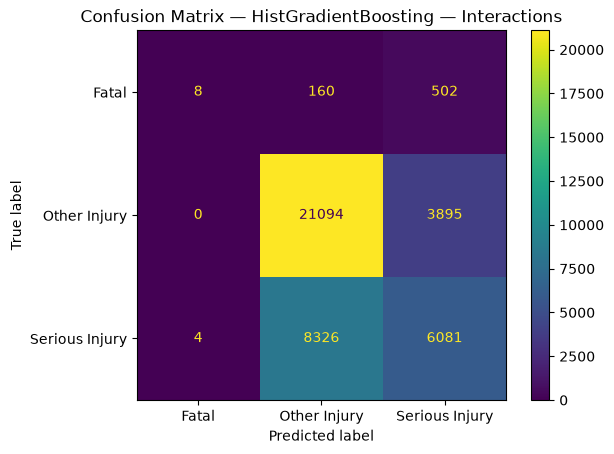

In [17]:
model_objects = {
    "HistGradientBoosting — Original": (hist_base_result, hist_base_pred),
    "HistGradientBoosting — Interactions": (hist_eng_result, hist_eng_pred),
    "XGBoost — Original": (xgb_base_result, xgb_base_pred),
    "XGBoost — Interactions": (xgb_eng_result, xgb_eng_pred),
    "LightGBM — Original": (lgb_base_result, lgb_base_pred),
    "LightGBM — Interactions": (lgb_eng_result, lgb_eng_pred),
}

best_name = max(
    model_objects,
    key=lambda name: model_objects[name][0]["Macro F1"]
)

best_result, best_pred = model_objects[best_name]

print("Highest Macro F1 in this interaction experiment:")
print(best_name)
print(f"Macro F1: {best_result['Macro F1']:.4f}")

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fatal", "Other Injury", "Serious Injury"]
)
disp.plot()
plt.title(f"Confusion Matrix — {best_name}")
plt.show()


## 17. Save engineered interaction metadata and results


In [18]:
all_results.to_csv(
    os.path.join(DATA_DIR, "feature_interaction_model_comparison.csv"),
    index=False
)

interaction_summary.to_csv(
    os.path.join(DATA_DIR, "engineered_interaction_features.csv"),
    index=False
)

fatal_comparison.to_csv(
    os.path.join(DATA_DIR, "feature_interaction_fatal_class_comparison.csv"),
    index=False
)

print("Saved:")
print("- feature_interaction_model_comparison.csv")
print("- engineered_interaction_features.csv")
print("- feature_interaction_fatal_class_comparison.csv")


Saved:
- feature_interaction_model_comparison.csv
- engineered_interaction_features.csv
- feature_interaction_fatal_class_comparison.csv


# Conclusion

Feature engineering is considered successful only if the engineered interactions produce a meaningful improvement over the corresponding original-feature model.

### Interpretation rules

- If Macro F1 improves clearly, the interaction features provide useful predictive information.
- If performance is approximately unchanged, the original ensemble models may already be learning much of the interaction structure automatically.
- If performance decreases, the engineered interactions may be adding sparsity/noise rather than useful information.
- Fatal-class recall should be reported alongside macro metrics because the target is highly imbalanced.

This experiment therefore tests the hypothesis rather than assuming that interaction features are beneficial.
